**Name**: Abhi Mondal       
*Roll No*: 22MS075

In [1]:
# packages
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from numba import njit              # used for fast compilation (for installation, run "pip install numba")

In [3]:
@njit
# input: population size, w (parameter for finite population) ,pay off matrix, initial of C (in C vs D game)
def moran_fixation(N, w, payoff_matrix, initial_C = 1):
    initial_D = N - initial_C       # number of D player

    total_payoff_C = (payoff_matrix[0][0]*(initial_C - 1) + payoff_matrix[0][1]*(N - initial_C))/(N - 1)    # F_i
    total_payoff_D = (payoff_matrix[1][0]*(initial_C) + payoff_matrix[1][1]*(N - initial_C - 1))/(N - 1)    # G_i
    fitness_C = (1 - w + w*total_payoff_C)      # f_i
    fitness_D = (1 - w + w*total_payoff_D)      # g_i

    # initialize the population
    pop = np.ones(N,dtype=np.int32)
    pop[:initial_C] = 0             # C -> 0 and D -> 1
    np.random.shuffle(pop)          # shuffle the population

    # track the count of A
    count_C = initial_C
    freq_C_hist = [np.float64(count_C)/N]

    steps = 0

    # run until fixation (C reaches 0 or N)
    while count_C > 0 and count_C < N:

        parent_idx = -1

        # selection for reproduction
        while parent_idx == -1:
            candidate = np.random.randint(0, N) # Pick a Random member
            
            # compare with the fitness for reproduction
            if pop[candidate] == 0:     # C player
                if np.random.random() < fitness_C:
                    parent_idx = candidate
            else:                       # D player
                if np.random.random() < fitness_D:
                    parent_idx = candidate

        
        # selection for death
        death_idx = np.random.randint(0, N)
        
        # exchange
        old_trait = pop[death_idx]
        new_trait = pop[parent_idx]
        
        # update
        pop[death_idx] = new_trait
        
        # tracking of frequencies
        if old_trait == 0 and new_trait == 1:
            count_C -= 1
        elif old_trait == 1 and new_trait == 0:
            count_C += 1
            
        steps += 1

        # record frequency of C
        freq_C_hist.append(count_C / N)
    
    freq_C_hist.append(count_C / N) # last one
    
    fixed_C = 0
    # check if C is fixed or not
    if freq_C_hist[-1] == 1:
        fixed_C = 1
    
    return  fixed_C,freq_C_hist

In [2]:
@njit
def moran_fixation(N, w, payoff_matrix, initial_C):
    count_C = initial_C

    while count_C > 0 and count_C < N:
        count_D = N - count_C   # initial D numbers

        # Payoffs at current composition
        total_payoff_C = (payoff_matrix[0][0]*(count_C - 1) + payoff_matrix[0][1]*count_D) / (N - 1)    #F_i
        total_payoff_D = (payoff_matrix[1][0]*count_C + payoff_matrix[1][1]*(count_D - 1)) / (N - 1)    #G_i

        fitness_C = 1.0 - w + w * total_payoff_C    #f_i
        fitness_D = 1.0 - w + w * total_payoff_D    #g_i

        # Reproduction: proportional to fitness -> normalized
        total_fitness = count_C * fitness_C + count_D * fitness_D
        
        if np.random.random() < (count_C * fitness_C) / total_fitness:
            reproducer = 0      # C is selected for reproduce
        else:
            reproducer = 1      # D is selected for reproduce

        # Death: uniform random
        if np.random.random() < (count_C / N):
            death = 0 
        else:
            death = 1

        # Update count
        if reproducer == 0 and death == 1:
            count_C += 1
        elif reproducer == 1 and death == 0:
            count_C -= 1

    if count_C == N:
        return 1
    else:
        return 0

In [3]:
@njit
# input: population number, number of trials, payoff matrix
# output: probability of fixation of C
def fixation_probability(N,Nt,payoff_matrix):
    count_fix_C = 0
    # run for Nt trials
    for _ in range(Nt):
        x = moran_fixation(N = N, w = 1, payoff_matrix= payoff_matrix, initial_C = 1)
        count_fix_C = count_fix_C + x
    
    return count_fix_C/Nt   # probability

In [4]:
# parameters
m = 10 # number of rounds 

# TFT-ALLD payoff matrix
a = 3; b = 0; c = 5; d = 1;

payoff_matrix = np.array([
    [m*a, b+ (m-1)*d],
    [c + (m-1)*d, m*d]
], dtype=np.float64)

# array of population size
N_values = np.array([100,200,300,400,600,800,1000])

# trials 
Nt = 1000

In [5]:
rho_values = np.zeros(len(N_values))

for i in range(len(N_values)):
    rho_values[i] = fixation_probability(N = N_values[i],Nt=max(Nt, 5 * N_values[i]),payoff_matrix=payoff_matrix)

N_rho_values = N_values * rho_values

In [6]:
print(rho_values)

[0.04       0.024      0.01466667 0.0105     0.004      0.00275
 0.0006    ]


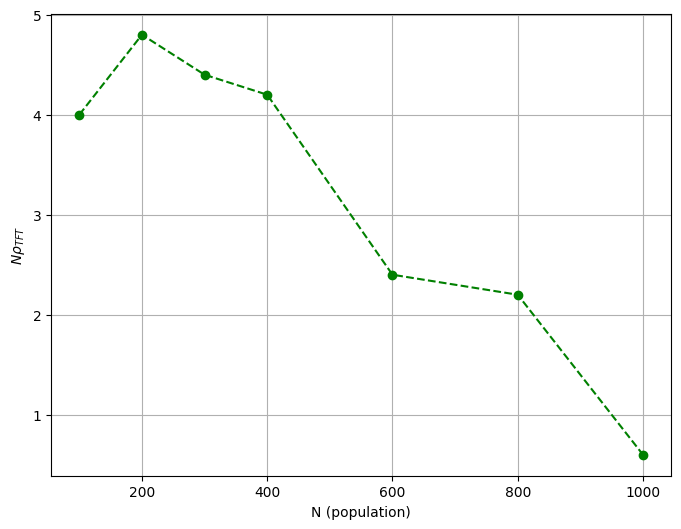

In [7]:
plt.figure(figsize= (8,6))
plt.plot(N_values,N_rho_values, marker = 'o', color = 'green', linestyle='dashed')
plt.xlabel("N (population)")
plt.ylabel(r"$N\rho_{TFT}$")
plt.grid(True)
plt.show()